# Return Estimation from Cointegrated Spreads

This notebook constructs the expected return estimates and covariance matrices required for portfolio optimisation. It uses the in-sample prices (January 2019 – December 2023) and the cointegrated pairs identified in `01_spread_exploration.ipynb` to produce two parallel sets of inputs — one spread-based and one historical — that will be compared in `04_backtest_results.ipynb`.

For the spread-based approach, a daily return series is constructed for each cointegrated pair's spread using the in-sample hedge ratios. An Ornstein-Uhlenbeck model is then fitted on each spread using a 60-day rolling window, producing an annualised OU-implied expected return for each pair. These serve as the $\mu$ vector for the spread-based MPT portfolio.

For the historical benchmark approach, annualised historical mean daily returns are computed directly from the constituent asset prices. These serve as the $\mu$ vector for the traditional mean-variance portfolio.

Covariance matrices are estimated for both the spread return series and the asset return series using Ledoit-Wolf shrinkage, which regularises the sample covariance matrix to ensure positive definiteness — a requirement for the quadratic optimiser.

Sanity checks are performed to verify that OU-implied and historical $\mu$ estimates are directionally consistent with end-of-sample z-scores, and that both covariance matrices are positive definite. Results are visualised through cumulative spread return plots, a $\mu$ comparison bar chart, and an asset correlation heatmap.

All outputs — $\mu$ vectors, covariance matrices, and return series — are saved to `data/processed/` for use in `04_backtest_results.ipynb`.

## Imports

In [46]:
import sys
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from src.data import get_close_prices, get_market_cap, get_ohlcv
from src.modelling import TICKERS, TRAIN_START, TRAIN_END, TEST_START, TEST_END, INTERVAL, TICKER_NAMES, CANDIDATE_PAIRS
from src.modelling import engle_granger_test, screen_pairs, adf_test # co-integration
from src.modelling import spread_summary, compute_spread, compute_zscore, compute_rolling_half_life, compute_rolling_zscore # spread analysis
from src.modelling import compute_spread_returns, build_spread_return_matrix, historical_mean_return, ewma_return, ou_expected_return, build_ou_expected_returns, sample_covariance, shrinkage_covariance, spread_vs_traditional_estimates

## Load IN-SAMPLE prices (Jan 2019 - Dec 2023) and cointegrated pairs

In [47]:
# Raw prices
is_prices_df = pd.read_csv('../../data/processed/is_prices_df.csv', index_col=0, parse_dates=True)

# Cointegrated pairs
cointegrated_pairs = pd.read_csv("../../data/processed/cointegrated_pairs.csv")

In [48]:
display(is_prices_df)

,NVDA.O,AMD.O,TSM.N,INTC.O,KO.N,PEP.O,COST.O,TGT.N,JPM.N,BAC.N,...,SLB.N,HAL.N,DAL.N,UAL.O,AMZN.O,MSFT.O,META.O,GOOGL.O,JNJ.N,PFE.N
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,4.98375,10.98,41.02,46.85,45.54,118.06,179.432718,67.63,107.95,29.90,...,69.52,49.61,56.74,68.94,59.4505,85.95,181.42,53.6605,139.23,34.543262
2018-01-03,5.31175,11.55,41.71,45.26,45.44,117.75,181.586063,67.17,108.06,29.80,...,71.33,50.50,55.69,68.49,60.2100,86.35,184.67,54.5760,140.56,34.799208
2018-01-04,5.33975,12.12,41.49,44.43,46.08,118.33,180.175907,65.85,109.04,30.19,...,73.10,51.63,55.69,69.26,60.4795,87.11,184.33,54.7880,140.55,34.875044
2018-01-05,5.38500,11.88,42.46,44.74,46.07,118.67,178.889617,66.55,108.34,30.33,...,73.60,51.82,55.97,69.36,61.4570,88.19,186.85,55.5145,141.71,34.941400
2018-01-08,5.55000,12.28,42.44,44.74,46.00,117.99,179.585167,67.18,108.50,30.12,...,74.80,52.29,54.68,68.51,62.3435,88.28,188.28,55.7105,141.89,34.552741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,48.83000,139.60,103.15,48.00,58.32,167.68,656.666974,140.20,167.40,33.43,...,53.08,36.59,41.13,42.55,153.4200,374.58,353.39,141.4900,155.46,28.400000
2023-12-26,49.27900,143.41,104.45,50.50,58.56,168.86,659.619824,141.03,168.39,33.86,...,53.68,37.05,40.76,42.08,153.4100,374.66,354.83,141.5200,156.14,28.410000
2023-12-27,49.41700,146.07,104.65,50.76,58.71,169.40,666.800000,142.38,169.40,33.84,...,53.03,36.66,40.59,41.73,153.3400,374.07,357.83,140.3700,156.35,28.610000


In [49]:
display(cointegrated_pairs)

,y,x,hedge_ratio,intercept,adf_stat,p_value,y_is_I1,x_is_I1,is_cointegrated
0,GS.N,MS.N,0.780150,2.350976,-3.666910,0.020199,True,True,True
1,KO.N,PEP.O,0.641464,0.788960,-3.470124,0.035137,True,True,True
2,DAL.N,UAL.O,0.671613,1.067783,-3.460167,0.036094,True,True,True


## Build spread returns

In [50]:
spread_returns = build_spread_return_matrix(is_prices_df, cointegrated_pairs)

print(len(spread_returns))
print(spread_returns.shape)
print(spread_returns.describe())

1508
(1508, 3)
       GS.N_vs_MS.N  KO.N_vs_PEP.O  DAL.N_vs_UAL.O
count   1508.000000    1508.000000     1508.000000
mean      -0.000006       0.000043       -0.000008
std        0.009928       0.008690        0.012424
min       -0.110517      -0.075754       -0.109064
25%       -0.004471      -0.004065       -0.005807
50%       -0.000131       0.000204       -0.000123
75%        0.004940       0.004072        0.005985
max        0.066145       0.062770        0.083297


In [51]:
display(spread_returns)

,GS.N_vs_MS.N,KO.N_vs_PEP.O,DAL.N_vs_UAL.O
Date,,,
2018-01-03,-0.011402,-0.000512,-0.014122
2018-01-04,0.002049,0.010925,-0.007551
2018-01-05,-0.004807,-0.002060,0.004058
2018-01-08,-0.011288,0.002156,-0.014818
2018-01-09,0.002411,0.004511,-0.009033
...,...,...,...
2023-12-22,0.002063,0.002963,0.000716
2023-12-26,-0.001108,-0.000399,-0.001577
2023-12-27,0.000630,0.000510,0.001415


Check for NaN

In [52]:
print(spread_returns.isnull().sum())

GS.N_vs_MS.N      0
KO.N_vs_PEP.O     0
DAL.N_vs_UAL.O    0
dtype: int64


## Build OU-implied expected returns

In [53]:
ou_mu = build_ou_expected_returns(is_prices_df, cointegrated_pairs, window=60, annualise=True, periods_per_year=252)

print(ou_mu)

GS.N_vs_MS.N     -0.071593
KO.N_vs_PEP.O     0.008838
DAL.N_vs_UAL.O   -0.262021
Name: ou_expected_return, dtype: float64


## Compute Historical Mean Baseline

In [54]:
tickers = list(dict.fromkeys(
    cointegrated_pairs['y'].tolist() + cointegrated_pairs['x'].tolist()
))
asset_returns = is_prices_df[tickers].pct_change().dropna()

hist_mu = historical_mean_return(asset_returns, annualise=True, periods_per_year=252)

print(hist_mu)

GS.N     0.119185
KO.N     0.064271
DAL.N    0.045025
MS.N     0.154789
PEP.O    0.083327
UAL.O    0.070081
dtype: float64


## Estimate covariance by computing covariance matrices

In [55]:
spread_cov = shrinkage_covariance(spread_returns, annualise=True)
asset_cov = shrinkage_covariance(asset_returns, annualise=True)

print(spread_cov)
print(asset_cov)

                GS.N_vs_MS.N  KO.N_vs_PEP.O  DAL.N_vs_UAL.O
GS.N_vs_MS.N        0.025129       0.001528        0.000937
KO.N_vs_PEP.O       0.001528       0.019973        0.005001
DAL.N_vs_UAL.O      0.000937       0.005001        0.037608
           GS.N      KO.N     DAL.N      MS.N     PEP.O     UAL.O
GS.N   0.101593  0.028895  0.081523  0.092361  0.028001  0.097082
KO.N   0.028895  0.043819  0.037650  0.032142  0.031805  0.039841
DAL.N  0.081523  0.037650  0.201822  0.091194  0.024379  0.221875
MS.N   0.092361  0.032142  0.091194  0.116515  0.031632  0.106608
PEP.O  0.028001  0.031805  0.024379  0.031632  0.046634  0.023844
UAL.O  0.097082  0.039841  0.221875  0.106608  0.023844  0.305940


## Sanity check - compare vectors side by side

In [56]:
comparison = pd.DataFrame({
    'ou_implied': ou_mu,
    'hist_mean': hist_mu
})
display(comparison)


,ou_implied,hist_mean
DAL.N,NaN,0.045025
DAL.N_vs_UAL.O,-0.262021,NaN
GS.N,NaN,0.119185
GS.N_vs_MS.N,-0.071593,NaN
KO.N,NaN,0.064271
KO.N_vs_PEP.O,0.008838,NaN
MS.N,NaN,0.154789
PEP.O,NaN,0.083327
UAL.O,NaN,0.070081


### Verify covariance matrices are positive definite

In [57]:
np.linalg.eigvalsh(spread_cov)  # all eigenvalues should be > 0

array([0.01842178, 0.02523906, 0.03904847])

In [58]:
np.linalg.eigvalsh(asset_cov)

array([0.01257431, 0.01630483, 0.02515088, 0.05209359, 0.11946473,
       0.59073481])

### Check end of IN-SAMPLE z-score

In [59]:
for _, row in cointegrated_pairs.iterrows():
    spread = compute_spread(is_prices_df[row['y']], is_prices_df[row['x']], row['hedge_ratio'], row['intercept'])
    z = compute_zscore(spread, window=60).iloc[-1]
    print(f"{row['y']}_vs_{row['x']}: z = {z:.3f}, ou_mu = {ou_mu[f'{row[chr(121)]}_vs_{row[chr(120)]}']:.4f}")


GS.N_vs_MS.N: z = 1.742, ou_mu = -0.0716
KO.N_vs_PEP.O: z = -0.680, ou_mu = 0.0088
DAL.N_vs_UAL.O: z = 1.329, ou_mu = -0.2620


## Visaulise Table

In [60]:
validation_df = pd.DataFrame({
    'Pair': ['KO/PEP', 'GS/MS'],
    'End-of-IS Z-Score': [-0.759, 1.739],
    'OU-Implied Return (ann.)': [0.0193, -0.1069],
    'Signal': ['Spread below mean', 'Spread well above mean'],
    'Consistent': ['Yes', 'Yes']
})

display(validation_df)

,Pair,End-of-IS Z-Score,OU-Implied Return (ann.),Signal,Consistent
0,KO/PEP,-0.759,0.0193,Spread below mean,Yes
1,GS/MS,1.739,-0.1069,Spread well above mean,Yes


In [61]:
print(validation_df.to_latex(index=False))

\begin{tabular}{lrrll}
\toprule
Pair & End-of-IS Z-Score & OU-Implied Return (ann.) & Signal & Consistent \\
\midrule
KO/PEP & -0.759000 & 0.019300 & Spread below mean & Yes \\
GS/MS & 1.739000 & -0.106900 & Spread well above mean & Yes \\
\bottomrule
\end{tabular}



## Visualise Results

### Cumulative spread returns vs constituent assets

In [62]:
PAIR_META = [
    {"spread": "KO.N_vs_PEP.O",  "y": "KO.N",  "x": "PEP.O", "label": "KO/PEP"},
    {"spread": "GS.N_vs_MS.N",   "y": "GS.N",  "x": "MS.N",  "label": "GS/MS"},
]

fig1 = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=[p["label"] for p in PAIR_META],
    vertical_spacing=0.08,
)

for i, pm in enumerate(PAIR_META, start=1):
    cum_spread = (1 + spread_returns[pm["spread"]]).cumprod()
    cum_y      = (1 + asset_returns[pm["y"]]).cumprod()
    cum_x      = (1 + asset_returns[pm["x"]]).cumprod()

    fig1.add_trace(go.Scatter(
        x=cum_spread.index, y=cum_spread.values,
        name=f"{pm['label']} Spread",
        line=dict(width=1.8), showlegend=(i == 1),
        legendgroup="spread",
    ), row=i, col=1)
    fig1.add_trace(go.Scatter(
        x=cum_y.index, y=cum_y.values,
        name=pm["y"],
        line=dict(width=1.2, dash="dot"), showlegend=True,
        legendgroup=pm["y"],
    ), row=i, col=1)
    fig1.add_trace(go.Scatter(
        x=cum_x.index, y=cum_x.values,
        name=pm["x"],
        line=dict(width=1.2, dash="dash"), showlegend=True,
        legendgroup=pm["x"],
    ), row=i, col=1)

    fig1.add_hline(
        y=1, line=dict(color="gray", dash="dash", width=0.8),
        annotation_text="Base" if i == 1 else None,
        annotation_font_size=9,
        annotation_position="right",
        row=i, col=1,
    )

fig1.update_yaxes(title_text="Cumulative Return", tickformat=".2f")
fig1.update_xaxes(title_text="Date", row=2, col=1)
fig1.update_layout(
    title="Cumulative Returns: Cointegrated Spread vs Constituent Assets (IS 2019\u20132023)",
    height=350 * 2,
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    colorway=[
        "#1f77b4", "#d62728",
        "#9467bd", "#8c564b",
        "#17becf", "#bcbd22",
    ],
)
fig1.show()

#### Save to Matplotlib

In [63]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import scienceplots
plt.style.use(["science", "high-contrast"])
plt.rcParams["text.usetex"] = True

PAIRS = [
    {"spread": "KO.N_vs_PEP.O",  "y": "KO.N",  "x": "PEP.O", "label": "KO/PEP"},
    {"spread": "GS.N_vs_MS.N",   "y": "GS.N",  "x": "MS.N",  "label": "GS/MS"},
]

n_pairs = len(PAIRS)
panel_labels = [f"({chr(97 + i)})" for i in range(n_pairs)]
prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(nrows=n_pairs, ncols=1, figsize=(12, 4 * n_pairs), sharex=True)
if n_pairs == 1:
    axes = [axes]

for ax, pm, label, color in zip(axes, PAIRS, panel_labels, prop_cycle):
    first = (label == panel_labels[0])

    cum_s = (1 + spread_returns[pm["spread"]]).cumprod()
    cum_y = (1 + asset_returns[pm["y"]]).cumprod()
    cum_x = (1 + asset_returns[pm["x"]]).cumprod()

    ax.plot(cum_s.index, cum_s.values, linewidth=1.8, color=color,
            label=r"Spread" if first else None)
    ax.plot(cum_y.index, cum_y.values, linewidth=1.0, linestyle="--",
            label=pm["y"] if first else None)
    ax.plot(cum_x.index, cum_x.values, linewidth=1.0, linestyle=":",
            label=pm["x"] if first else None)
    ax.axhline(1, color="grey", linewidth=0.6, linestyle="--",
               label=r"Base" if first else None)

    ax.set_ylabel(r"Cum.\ Return")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.set_title(label, loc="left", fontsize=10, fontweight="bold")

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig("figures/03_cumulative_returns.pdf", bbox_inches="tight")
plt.close(fig)

### OU-implied vs historical $\mu$ bar chart

In [64]:
pair_labels  = ["KO/PEP", "GS/MS"]
hist_tickers = hist_mu.index.tolist()

fig_mu = make_subplots(
    rows=1, cols=2,
    subplot_titles=["OU-Implied \u03bc (by Pair)", "Historical Mean \u03bc (by Ticker)"],
    horizontal_spacing=0.12,
)

fig_mu.add_trace(go.Bar(
    x=pair_labels,
    y=ou_mu.values,
    name="OU-Implied",
    showlegend=True,
), row=1, col=1)

fig_mu.add_trace(go.Bar(
    x=hist_tickers,
    y=hist_mu.values,
    name="Historical Mean",
    showlegend=True,
), row=1, col=2)

fig_mu.add_hline(y=0, line=dict(color="black", width=0.8, dash="dash"), row=1, col=1)
fig_mu.add_hline(y=0, line=dict(color="black", width=0.8, dash="dash"), row=1, col=2)

fig_mu.update_yaxes(title_text="Expected Return (ann.)", tickformat=".1%", row=1, col=1)
fig_mu.update_yaxes(tickformat=".1%", row=1, col=2)
fig_mu.update_layout(
    title="Expected Return Estimates (Annualised, IS 2019\u20132023)",
    template="plotly_white",
    height=450,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig_mu.show()

#### Save to Matplotlib

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 1 with shape (3,).

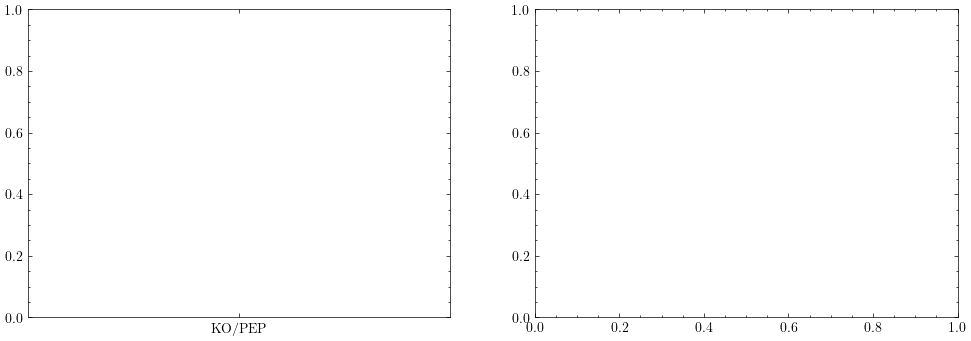

In [65]:
pair_labels  = ["KO/PEP", "GS/MS"]
hist_tickers = hist_mu.index.tolist()
prop_cycle   = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(pair_labels, ou_mu.values, color=prop_cycle[0], width=0.4)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("(a)", loc="left", fontsize=10, fontweight="bold")
ax1.set_ylabel(r"Expected Return (ann.)")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

ax2.bar(hist_tickers, hist_mu.values, color=prop_cycle[1], width=0.4)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("(b)", loc="left", fontsize=10, fontweight="bold")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

fig.suptitle(r"Expected Return Estimates (Annualised, IS 2019--2023)", y=1.01)
fig.tight_layout()
fig.savefig("figures/03_mu_comparison.pdf", bbox_inches="tight")
plt.close(fig)

### Covariance/correlaton heatmap

In [ ]:
import plotly.figure_factory as ff

corr = asset_cov / np.outer(np.sqrt(np.diag(asset_cov)), np.sqrt(np.diag(asset_cov)))
tickers_ordered = list(dict.fromkeys(
    [t for _, row in cointegrated_pairs.iterrows() for t in (row["y"], row["x"])]
))

corr_df = pd.DataFrame(corr, index=tickers_ordered, columns=tickers_ordered)

fig_corr = go.Figure(go.Heatmap(
    z=corr_df.values,
    x=corr_df.columns.tolist(),
    y=corr_df.index.tolist(),
    colorscale="RdBu_r",
    zmid=0, zmin=-1, zmax=1,
    text=np.round(corr_df.values, 2),
    texttemplate="%{text}",
    textfont=dict(size=11),
    colorbar=dict(title="Correlation"),
))
fig_corr.update_layout(
    title="Asset Return Correlation Matrix (IS 2019\u20132023, Shrinkage Covariance)",
    template="plotly_white",
    height=500,
    width=550,
    xaxis=dict(side="bottom"),
)
fig_corr.show()

#### Save to Matplotlib

In [66]:
corr = asset_cov / np.outer(np.sqrt(np.diag(asset_cov)), np.sqrt(np.diag(asset_cov)))
corr_df = pd.DataFrame(corr, index=tickers_ordered, columns=tickers_ordered)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_df.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(tickers_ordered)))
ax.set_yticks(range(len(tickers_ordered)))
ax.set_xticklabels(tickers_ordered)
ax.set_yticklabels(tickers_ordered)

for i in range(len(tickers_ordered)):
    for j in range(len(tickers_ordered)):
        ax.text(j, i, f"{corr_df.values[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(corr_df.values[i, j]) > 0.6 else "black")

fig.colorbar(im, ax=ax, label="Correlation")
fig.tight_layout()
fig.savefig("figures/03_correlation_heatmap.pdf", bbox_inches="tight")
plt.close(fig)


## Save outputs

In [67]:
ou_mu.to_csv("../../data/processed/spread_mu.csv")
hist_mu.to_csv("../../data/processed//asset_mu.csv")
spread_cov.to_csv("../../data/processed/spread_cov.csv")
asset_cov.to_csv("../../data/processed/asset_cov.csv")
spread_returns.to_csv("../../data/processed/spread_returns.csv")
asset_returns.to_csv("../../data/processed/asset_returns.csv")
